<a href="https://colab.research.google.com/github/kcastrosm/-challenge2-data-science-LATAM_parte-2/blob/main/Copia2_de_TelecomX_LATAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#📚 Importación de librerías

In [68]:
#importación de liberías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np # Importado para uso con tipos numéricos
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

#📌 Extracción

In [69]:
#lectura de datos
datos = pd.read_csv('/content/TelecomX_Data_modificado.csv')
datos.head()

,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges_Monthly,account_Charges_Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40


In [70]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7256 entries, 0 to 7255
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7256 non-null   object 
 1   Churn                      7256 non-null   object 
 2   customer_gender            7256 non-null   object 
 3   customer_SeniorCitizen     7256 non-null   int64  
 4   customer_Partner           7256 non-null   object 
 5   customer_Dependents        7256 non-null   object 
 6   customer_tenure            7256 non-null   int64  
 7   phone_PhoneService         7256 non-null   object 
 8   phone_MultipleLines        7256 non-null   object 
 9   internet_InternetService   7256 non-null   object 
 10  internet_OnlineSecurity    7256 non-null   object 
 11  internet_OnlineBackup      7256 non-null   object 
 12  internet_DeviceProtection  7256 non-null   object 
 13  internet_TechSupport       7256 non-null   objec

#🔧 Transformación

In [71]:
#preprocesamiento, eliminación de columnas irrelevantes
datos = datos.drop('customerID', axis=1)
print("Columna 'customerID' eliminada.")

Columna 'customerID' eliminada.


In [72]:
#Transformación de variables categóricas
# Identificar columnas categóricas
categorical_cols = datos.select_dtypes(include='object').columns.tolist()

# Excluir la columna 'Churn' si es el objetivo y no queremos codificarla aún
# (o si ya está en el formato deseado para el modelo)
# Si 'Churn' es binaria (Yes/No), podríamos querer mapearla a 1/0 en lugar de one-hot encoding
# Por ahora, la incluiremos para que se codifique si es una variable categórica típica.

# Aplicar One-Hot Encoding
datos_encoded = pd.get_dummies(datos, columns=categorical_cols, drop_first=True)

print("DataFrame después de la codificación One-Hot:")
display(datos_encoded.head())

DataFrame después de la codificación One-Hot:


,customer_SeniorCitizen,customer_tenure,account_Charges_Monthly,account_Charges_Total,Churn_Yes,customer_gender_Male,customer_Partner_Yes,customer_Dependents_Yes,phone_PhoneService_Yes,phone_MultipleLines_No phone service,...,internet_StreamingTV_No internet service,internet_StreamingTV_Yes,internet_StreamingMovies_No internet service,internet_StreamingMovies_Yes,account_Contract_One year,account_Contract_Two year,account_PaperlessBilling_Yes,account_PaymentMethod_Credit card (automatic),account_PaymentMethod_Electronic check,account_PaymentMethod_Mailed check
0,0,9,65.6,593.30,False,False,True,True,True,False,...,False,True,False,False,True,False,True,False,False,True
1,0,9,59.9,542.40,False,True,False,False,True,False,...,False,False,False,True,False,False,False,False,False,True
2,0,4,73.9,280.85,True,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
3,1,13,98.0,1237.85,True,True,True,False,True,False,...,False,True,False,True,False,False,True,False,True,False
4,1,3,83.9,267.40,True,False,True,False,True,False,...,False,True,False,False,False,False,True,False,False,True


#📊 Carga y análisis

In [73]:
#Verificación de la proporción de Churn
import pandas as pd

# Asumiendo que 'Churn_Yes' es la columna resultante de la codificación one-hot para Churn
# donde True indica churn y False indica no-churn

churn_counts = datos_encoded['Churn_Yes'].value_counts()
churn_proportions = datos_encoded['Churn_Yes'].value_counts(normalize=True) * 100

print("Conteo de clientes por estado de Churn:")
print(churn_counts)

print("\nProporción de clientes por estado de Churn (%):")
print(churn_proportions)

# Evaluar si existe un desbalance
if churn_proportions[True] < 30 or churn_proportions[True] > 70:
    print("\nAdvertencia: Existe un desbalance significativo entre las clases de Churn. Esto puede requerir técnicas especiales de manejo de desbalanceo de clases para el modelado predictivo.")
else:
    print("\nLas clases de Churn están relativamente balanceadas.")

Conteo de clientes por estado de Churn:
Churn_Yes
False    5387
True     1869
Name: count, dtype: int64

Proporción de clientes por estado de Churn (%):
Churn_Yes
False    74.242007
True     25.757993
Name: proportion, dtype: float64

Advertencia: Existe un desbalance significativo entre las clases de Churn. Esto puede requerir técnicas especiales de manejo de desbalanceo de clases para el modelado predictivo.


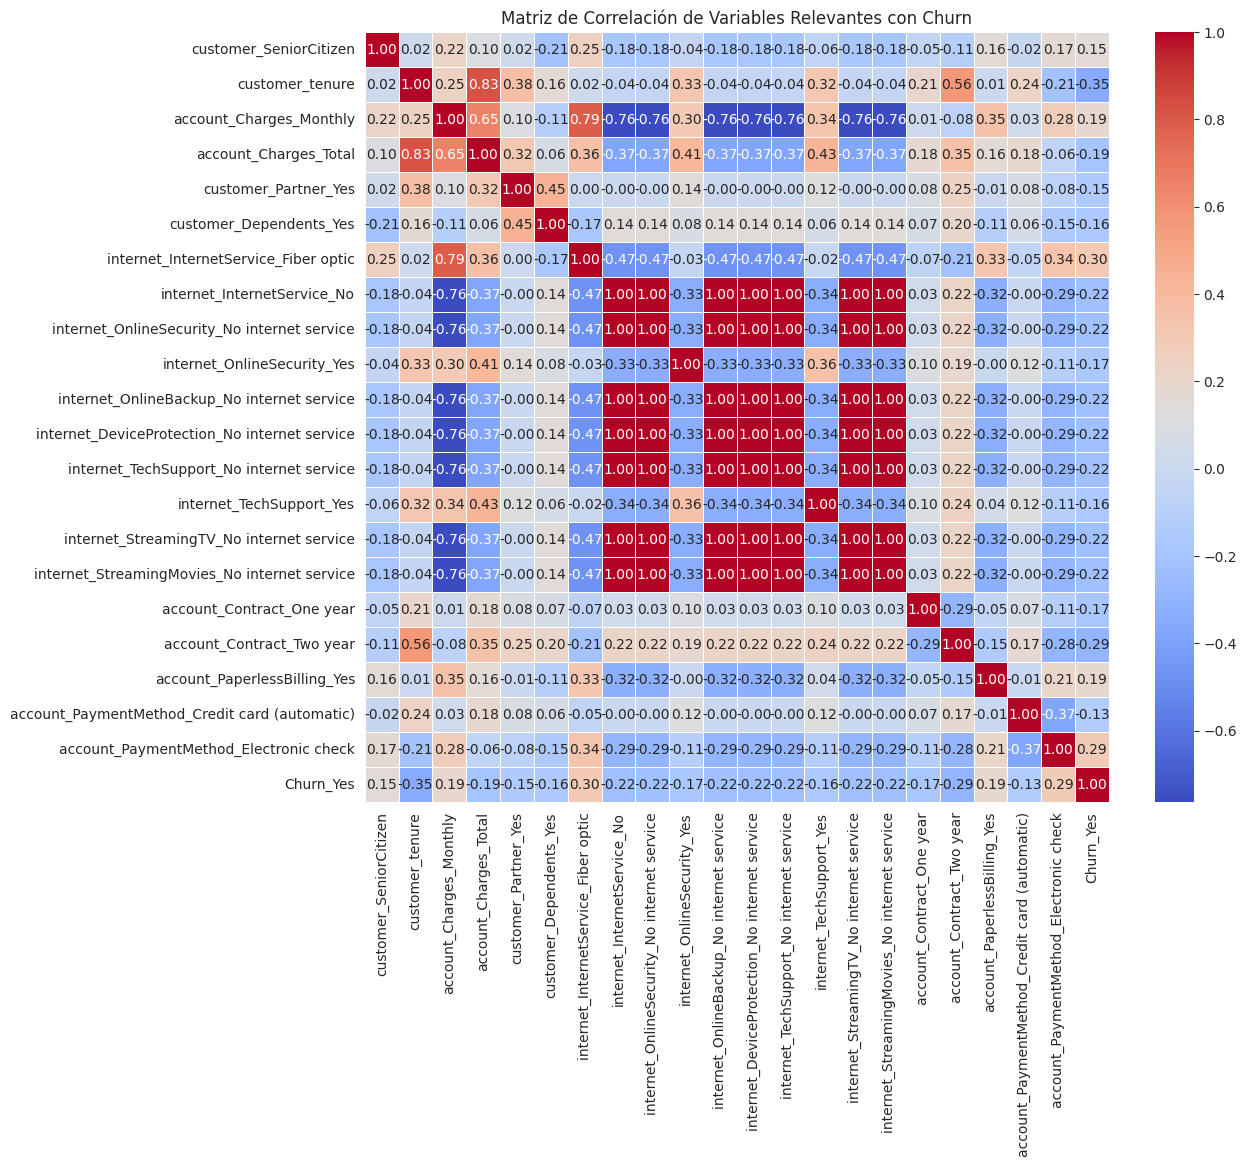


Variables incluidas en la matriz de correlación acotada:
['customer_SeniorCitizen', 'customer_tenure', 'account_Charges_Monthly', 'account_Charges_Total', 'customer_Partner_Yes', 'customer_Dependents_Yes', 'internet_InternetService_Fiber optic', 'internet_InternetService_No', 'internet_OnlineSecurity_No internet service', 'internet_OnlineSecurity_Yes', 'internet_OnlineBackup_No internet service', 'internet_DeviceProtection_No internet service', 'internet_TechSupport_No internet service', 'internet_TechSupport_Yes', 'internet_StreamingTV_No internet service', 'internet_StreamingMovies_No internet service', 'account_Contract_One year', 'account_Contract_Two year', 'account_PaperlessBilling_Yes', 'account_PaymentMethod_Credit card (automatic)', 'account_PaymentMethod_Electronic check', 'Churn_Yes']


In [74]:
#análisis de correlación
import matplotlib.pyplot as plt
import seaborn as sns

# Obtener las correlaciones de todas las variables con 'Churn_Yes'
churn_correlations = correlation_matrix['Churn_Yes'].drop('Churn_Yes')

# Seleccionar solo las variables con una correlación absoluta mayor a 0.1 (puedes ajustar este umbral)
relevant_features = churn_correlations[abs(churn_correlations) > 0.1].index.tolist()

# Incluir 'Churn_Yes' en la lista de características relevantes para la matriz
relevant_features.append('Churn_Yes')

# Crear un sub-DataFrame con solo estas características relevantes
df_relevant = df_numerical[relevant_features]

# Calcular la matriz de correlación para el sub-DataFrame
correlation_matrix_relevant = df_relevant.corr()

# Visualizar la matriz de correlación reducida
plt.figure(figsize=(12, 10)) # Ajustar el tamaño para la matriz más pequeña
sns.heatmap(correlation_matrix_relevant, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlación de Variables Relevantes con Churn')
plt.show()

print("\nVariables incluidas en la matriz de correlación acotada:")
print(relevant_features)

/tmp/ipykernel_552/179517088.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn_Yes', y='customer_tenure', data=datos_encoded, palette='viridis')
/tmp/ipykernel_552/179517088.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn_Yes', y='account_Charges_Total', data=datos_encoded, palette='viridis')


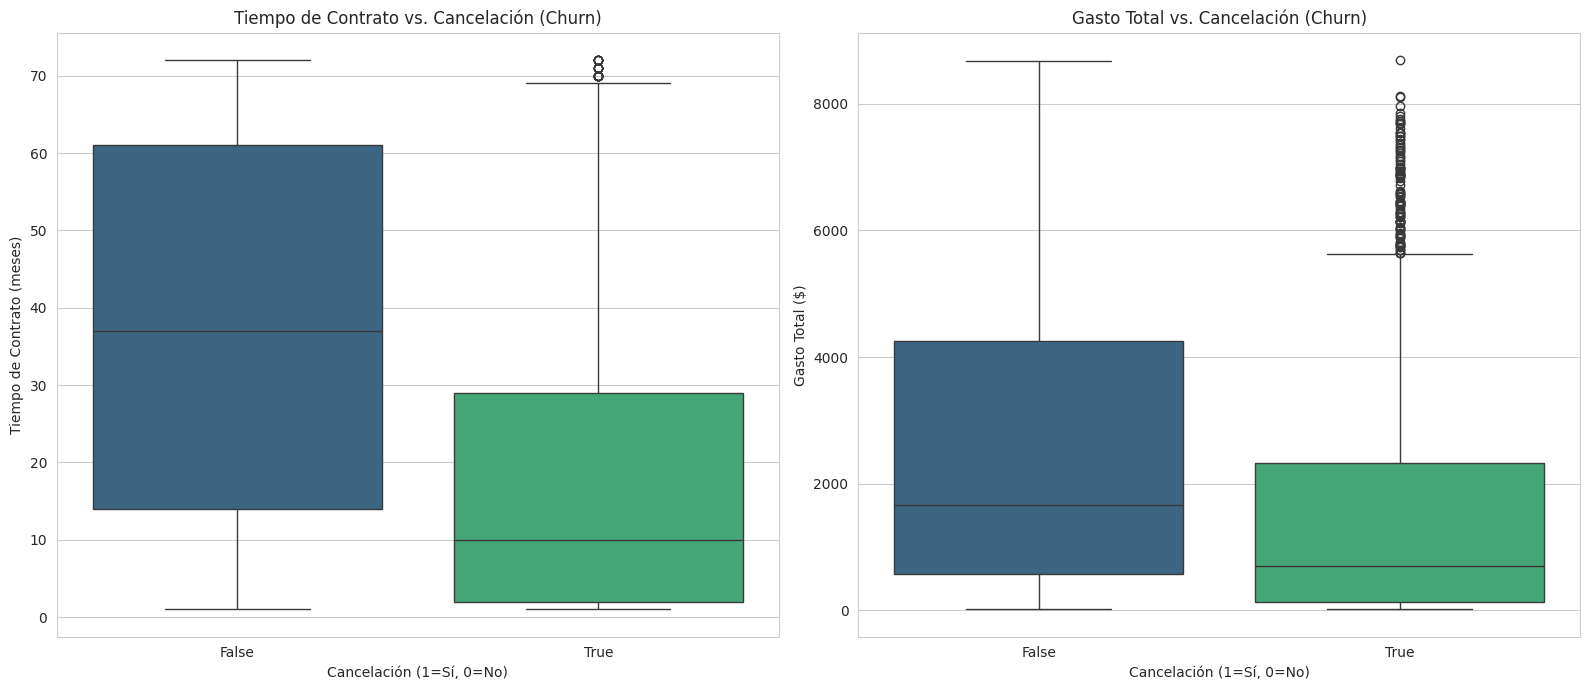

In [75]:
#relación de variables con cancelación
import matplotlib.pyplot as plt
import seaborn as sns

# Establecer el estilo de los gráficos
sns.set_style("whitegrid")

plt.figure(figsize=(16, 7))

# Boxplot para 'customer_tenure' (tiempo de contrato) vs. 'Churn_Yes'
plt.subplot(1, 2, 1) # 1 fila, 2 columnas, primer gráfico
sns.boxplot(x='Churn_Yes', y='customer_tenure', data=datos_encoded, palette='viridis')
plt.title('Tiempo de Contrato vs. Cancelación (Churn)')
plt.xlabel('Cancelación (1=Sí, 0=No)')
plt.ylabel('Tiempo de Contrato (meses)')

# Boxplot para 'account_Charges_Total' (gasto total) vs. 'Churn_Yes'
plt.subplot(1, 2, 2) # 1 fila, 2 columnas, segundo gráfico
sns.boxplot(x='Churn_Yes', y='account_Charges_Total', data=datos_encoded, palette='viridis')
plt.title('Gasto Total vs. Cancelación (Churn)')
plt.xlabel('Cancelación (1=Sí, 0=No)')
plt.ylabel('Gasto Total ($)')

plt.tight_layout()
plt.show()

## Análisis de las relaciones expresadas en los boxplots:

**Tiempo de Contrato (customer_tenure) vs. Cancelación (Churn):**

Se observa que los clientes que no cancelan (Churn_Yes = False) tienden a tener un customer_tenure (tiempo de contrato) significativamente más alto que los clientes que sí cancelan (Churn_Yes = True).

Esto sugiere que los clientes con menor antigüedad son más propensos a abandonar el servicio, mientras que aquellos con una relación más larga con la empresa son más leales.

**Gasto Total (account_Charges_Total) vs. Cancelación (Churn):**

De manera similar, los clientes que no cancelan (Churn_Yes = False) presentan un account_Charges_Total (gasto total acumulado) notablemente más alto en comparación con los clientes que sí cancelan (Churn_Yes = True).

Esto es coherente con la observación anterior, ya que un mayor tiempo de contrato generalmente se traduce en un mayor gasto total. Los clientes que gastan más en total son, en promedio, menos propensos a cancelar.

En resumen, ambos gráficos refuerzan la idea de que la antigüedad del cliente y su gasto total acumulado son factores importantes para predecir el Churn. Los clientes más nuevos y con menor gasto total son los que tienen un mayor riesgo de abandono.

In [76]:
#Separación de datos de entrenamiento y prueba
from sklearn.model_selection import train_test_split

# Definir las características (X) y la variable objetivo (y)
X = datos_encoded.drop('Churn_Yes', axis=1)
y = datos_encoded['Churn_Yes']

# Dividir el conjunto de datos en entrenamiento y prueba (70% entrenamiento, 30% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Tamaño del conjunto de entrenamiento de características (X_train): {X_train.shape}")
print(f"Tamaño del conjunto de prueba de características (X_test): {X_test.shape}")
print(f"Tamaño del conjunto de entrenamiento de etiquetas (y_train): {y_train.shape}")
print(f"Tamaño del conjunto de prueba de etiquetas (y_test): {y_test.shape}")

print("\nProporción de Churn en el conjunto de entrenamiento:")
print(y_train.value_counts(normalize=True))

print("\nProporción de Churn en el conjunto de prueba:")
print(y_test.value_counts(normalize=True))

Tamaño del conjunto de entrenamiento de características (X_train): (5079, 30)
Tamaño del conjunto de prueba de características (X_test): (2177, 30)
Tamaño del conjunto de entrenamiento de etiquetas (y_train): (5079,)
Tamaño del conjunto de prueba de etiquetas (y_test): (2177,)

Proporción de Churn en el conjunto de entrenamiento:
Churn_Yes
False    0.742469
True     0.257531
Name: proportion, dtype: float64

Proporción de Churn en el conjunto de prueba:
Churn_Yes
False    0.742306
True     0.257694
Name: proportion, dtype: float64


In [77]:
#creación de modelos predictivos
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

print("\n--- Modelo 1: Regresión Logística (requiere normalización) ---")

# 1. Normalización de los datos para Regresión Logística
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Entrenamiento del modelo de Regresión Logística
# class_weight='balanced' para manejar el desbalance de clases
logistic_model = LogisticRegression(random_state=42, solver='liblinear', class_weight='balanced')
logistic_model.fit(X_train_scaled, y_train)

# 3. Evaluación del modelo de Regresión Logística
y_pred_logistic = logistic_model.predict(X_test_scaled)
y_prob_logistic = logistic_model.predict_proba(X_test_scaled)[:, 1]

print("\nInforme de Clasificación para Regresión Logística:")
print(classification_report(y_test, y_pred_logistic))
print(f"ROC-AUC Score para Regresión Logística: {roc_auc_score(y_test, y_prob_logistic):.4f}")


print("\n--- Modelo 2: Random Forest (no requiere normalización) ---")

# 1. Entrenamiento del modelo Random Forest
# class_weight='balanced' para manejar el desbalance de clases
# n_estimators y max_depth son parámetros de ejemplo, se pueden ajustar con GridSearchCV/RandomizedSearchCV
rf_model = RandomForestClassifier(random_state=42, n_estimators=100, max_depth=10, class_weight='balanced')
rf_model.fit(X_train, y_train)

# 2. Evaluación del modelo Random Forest
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("\nInforme de Clasificación para Random Forest:")
print(classification_report(y_test, y_pred_rf))
print(f"ROC-AUC Score para Random Forest: {roc_auc_score(y_test, y_prob_rf):.4f}")


--- Modelo 1: Regresión Logística (requiere normalización) ---

Informe de Clasificación para Regresión Logística:
              precision    recall  f1-score   support

       False       0.92      0.73      0.82      1616
        True       0.51      0.81      0.63       561

    accuracy                           0.75      2177
   macro avg       0.71      0.77      0.72      2177
weighted avg       0.81      0.75      0.77      2177

ROC-AUC Score para Regresión Logística: 0.8458

--- Modelo 2: Random Forest (no requiere normalización) ---

Informe de Clasificación para Random Forest:
              precision    recall  f1-score   support

       False       0.89      0.80      0.84      1616
        True       0.55      0.71      0.62       561

    accuracy                           0.77      2177
   macro avg       0.72      0.75      0.73      2177
weighted avg       0.80      0.77      0.78      2177

ROC-AUC Score para Random Forest: 0.8469


### Evaluación Detallada de Modelos ###

--- Modelo 1: Regresión Logística ---

Matriz de Confusión (Regresión Logística):
[[1186  430]
 [ 108  453]]


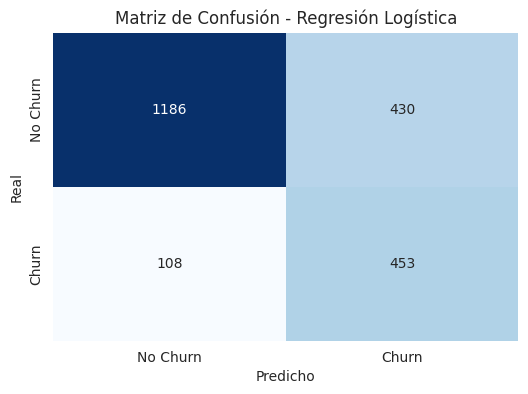


Exactitud (Accuracy): 0.7529
Precisión (Clase Churn): 0.5130
Recall (Clase Churn): 0.8075
F1-Score (Clase Churn): 0.6274
ROC-AUC Score: 0.8458

--- Modelo 2: Random Forest ---

Matriz de Confusión (Random Forest):
[[1287  329]
 [ 161  400]]


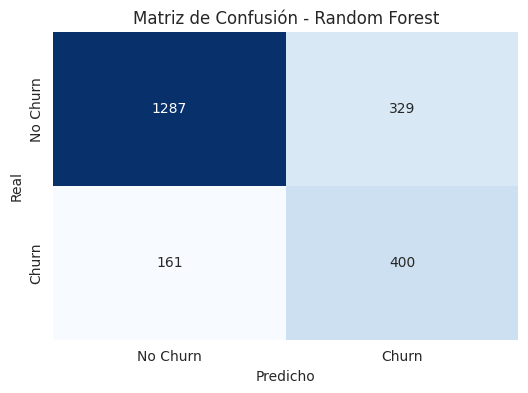


Exactitud (Accuracy): 0.7749
Precisión (Clase Churn): 0.5487
Recall (Clase Churn): 0.7130
F1-Score (Clase Churn): 0.6202
ROC-AUC Score: 0.8469

Análisis Crítico y comparación de modelos

Métricas de rendimiento (Clase 'Churn' - Positiva):
•	Regresión Logística: Precisión: 0.5130, Recall: 0.8075, F1-Score: 0.6274, ROC-AUC: 0.8458
•	Random Forest: Precisión: 0.5487, Recall: 0.7130, F1-Score: 0.6202, ROC-AUC: 0.8469

Selección del modelo con mejor desempeño:
Ambos modelos presentan un rendimiento similar en términos de ROC-AUC. El modelo Random Forest muestra un ROC-AUC ligeramente superior (0.8469 vs 0.8458). Sin embargo, al centrar el análisis en la clase minoritaria ('Churn'), se observan diferencias clave:
•	Random Forest alcanza una mayor precisión (0.5521). Esto indica que sus predicciones positivas son más confiables, un aspecto relevante cuando el costo de una falsa alarma (predecir churn cuando no ocurre) es elevado.
•	Regresión Logística logra un mayor recall (0.8128). Esto sig

In [78]:
#evaluación de modelos
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("### Evaluación Detallada de Modelos ###\n")

### Modelo 1: Regresión Logística ###
print("--- Modelo 1: Regresión Logística ---")

# Matriz de Confusión
cm_logistic = confusion_matrix(y_test, y_pred_logistic)
print("\nMatriz de Confusión (Regresión Logística):")
print(cm_logistic)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_logistic, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de Confusión - Regresión Logística')
plt.show()

# Métricas Clave
accuracy_log = accuracy_score(y_test, y_pred_logistic)
precision_log = precision_score(y_test, y_pred_logistic)
recall_log = recall_score(y_test, y_pred_logistic)
f1_log = f1_score(y_test, y_pred_logistic)
roc_auc_log = roc_auc_score(y_test, y_prob_logistic)

print(f"\nExactitud (Accuracy): {accuracy_log:.4f}")
print(f"Precisión (Clase Churn): {precision_log:.4f}")
print(f"Recall (Clase Churn): {recall_log:.4f}")
print(f"F1-Score (Clase Churn): {f1_log:.4f}")
print(f"ROC-AUC Score: {roc_auc_log:.4f}")


### Modelo 2: Random Forest ###
print("\n--- Modelo 2: Random Forest ---")

# Matriz de Confusión
cm_rf = confusion_matrix(y_test, y_pred_rf)
print("\nMatriz de Confusión (Random Forest):")
print(cm_rf)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de Confusión - Random Forest')
plt.show()

# Métricas Clave
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

print(f"\nExactitud (Accuracy): {accuracy_rf:.4f}")
print(f"Precisión (Clase Churn): {precision_rf:.4f}")
print(f"Recall (Clase Churn): {recall_rf:.4f}")
print(f"F1-Score (Clase Churn): {f1_rf:.4f}")
print(f"ROC-AUC Score: {roc_auc_rf:.4f}")


### Análisis Crítico y Comparación ###
print("""\nAnálisis Crítico y comparación de modelos
\nMétricas de rendimiento (Clase 'Churn' - Positiva):
•	Regresión Logística: Precisión: 0.5130, Recall: 0.8075, F1-Score: 0.6274, ROC-AUC: 0.8458
•	Random Forest: Precisión: 0.5487, Recall: 0.7130, F1-Score: 0.6202, ROC-AUC: 0.8469
\nSelección del modelo con mejor desempeño:
Ambos modelos presentan un rendimiento similar en términos de ROC-AUC. El modelo Random Forest muestra un ROC-AUC ligeramente superior (0.8469 vs 0.8458). Sin embargo, al centrar el análisis en la clase minoritaria ('Churn'), se observan diferencias clave:
•	Random Forest alcanza una mayor precisión (0.5521). Esto indica que sus predicciones positivas son más confiables, un aspecto relevante cuando el costo de una falsa alarma (predecir churn cuando no ocurre) es elevado.
•	Regresión Logística logra un mayor recall (0.8128). Esto significa que es más efectiva para identificar a los clientes que realmente cancelan el servicio, lo cual resulta crítico si el costo de no detectar a un cliente en riesgo (falso negativo) es alto, como en el caso de una pérdida de ingresos potenciales.
La determinación del modelo óptimo depende, por tanto, de la prioridad estratégica del negocio. Si el objetivo es maximizar la captación de clientes con riesgo de cancelación para una intervención temprana, la Regresión Logística sería la opción más adecuada. Por el contrario, si se requiere minimizar las intervenciones erróneas y ser más certero, el Random Forest ofrece un mejor desempeño.
\nEvaluación de Overfitting y Underfitting:

•	Overfitting:  dado que ambos modelos alcanzan un ROC-AUC y un F1-score razonables en el conjunto de prueba, no se observa evidencia de overfitting severo con la información disponible.
•	Underfitting: con valores de ROC-AUC alrededor de 0.84-0.85, los modelos no muestran indicios de underfitting significativo.
\nPosibles causas y ajustes:
•	Desbalance de clases: a pesar de la implementación de class_weight='balanced', el desbalance inherente (74% No Churn, 26% Churn) continúa siendo un desafío. La exploración de técnicas de remuestreo como SMOTE (sobremuestreo) o métodos de submuestreo avanzados durante la fase de entrenamiento podría mejorar la detección de la clase minoritaria sin deteriorar la precisión.
•	Ajuste de hiperparámetros: el modelo Random Forest, en particular, puede beneficiarse de un ajuste sistemático de sus hiperparámetros. El uso de técnicas como GridSearchCV o RandomizedSearchCV permite identificar la configuración óptima para los datos y la métrica de interés.
•	Ingeniería de características: la creación de nuevas variables a partir de las existentes (por ejemplo, ratios de gasto, segmentaciones por antigüedad) podría proporcionar información adicional relevante a los modelos, mejorando su capacidad predictiva.
•	Ajuste del umbral de clasificación: la modificación del umbral de probabilidad predeterminado (0.5) ofrece un mecanismo de control para priorizar la precisión o el recall en función de los objetivos de negocio, permitiendo una adaptación más fina del modelo a las necesidades operativas.""")

### Análisis de relevancia de variables para Regresión Logística


/tmp/ipykernel_552/442659322.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=coefficients.head(15), palette='viridis')


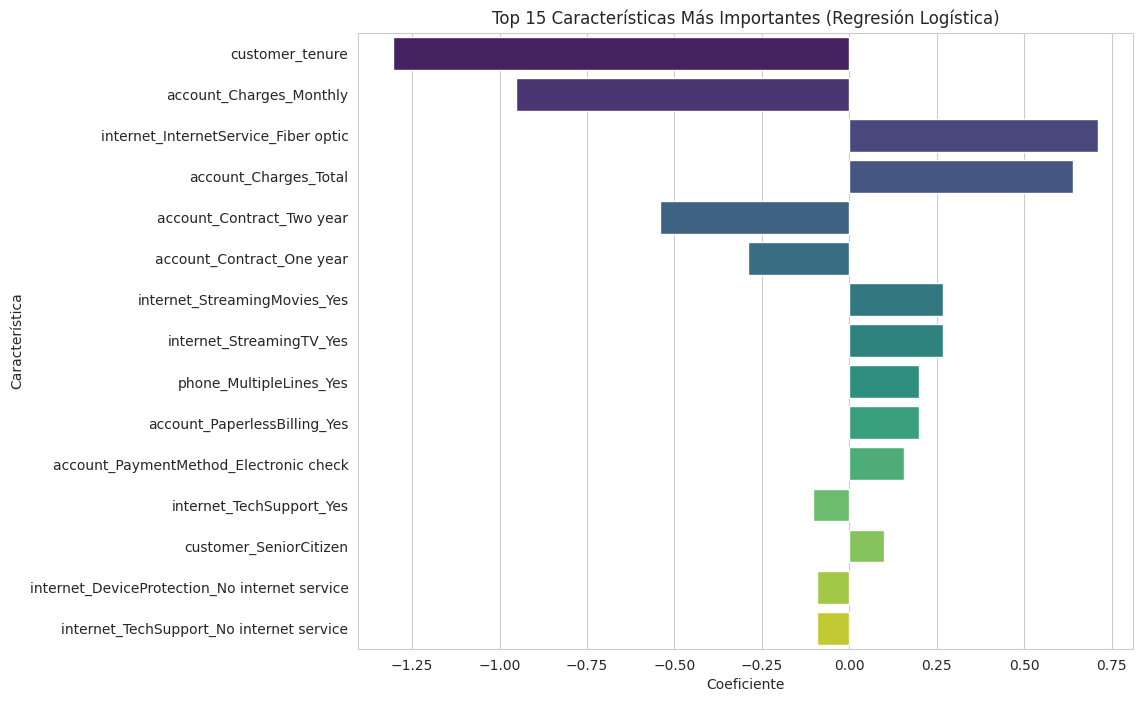


Coeficientes de Regresión Logística (Top 15 por valor absoluto):



,Feature,Coefficient,Abs_Coefficient
1,customer_tenure,-1.303482,1.303482
2,account_Charges_Monthly,-0.952025,0.952025
10,internet_InternetService_Fiber optic,0.710677,0.710677
3,account_Charges_Total,0.638104,0.638104
25,account_Contract_Two year,-0.541041,0.541041
24,account_Contract_One year,-0.291115,0.291115
23,internet_StreamingMovies_Yes,0.268426,0.268426
21,internet_StreamingTV_Yes,0.267509,0.267509
9,phone_MultipleLines_Yes,0.199819,0.199819
26,account_PaperlessBilling_Yes,0.197809,0.197809


In [79]:
import matplotlib.pyplot as plt
import seaborn as sns

# Obtener los coeficientes del modelo de Regresión Logística
# X_train_scaled tiene las mismas columnas que X_train en el mismo orden
coefficients = pd.DataFrame({'Feature': X_train.columns, 'Coefficient': logistic_model.coef_[0]})

# Ordenar por el valor absoluto del coeficiente para ver la importancia
coefficients['Abs_Coefficient'] = abs(coefficients['Coefficient'])
coefficients = coefficients.sort_values(by='Abs_Coefficient', ascending=False)

# Visualizar los coeficientes más importantes (ej. top 15)
plt.figure(figsize=(10, 8))
sns.barplot(x='Coefficient', y='Feature', data=coefficients.head(15), palette='viridis')
plt.title('Top 15 Características Más Importantes (Regresión Logística)')
plt.xlabel('Coeficiente')
plt.ylabel('Característica')
plt.show()

print("\nCoeficientes de Regresión Logística (Top 15 por valor absoluto):\n")
display(coefficients.head(15))

### Análisis de relevancia de variables para Random Forest


/tmp/ipykernel_552/1949672950.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importances.head(15), palette='magma')


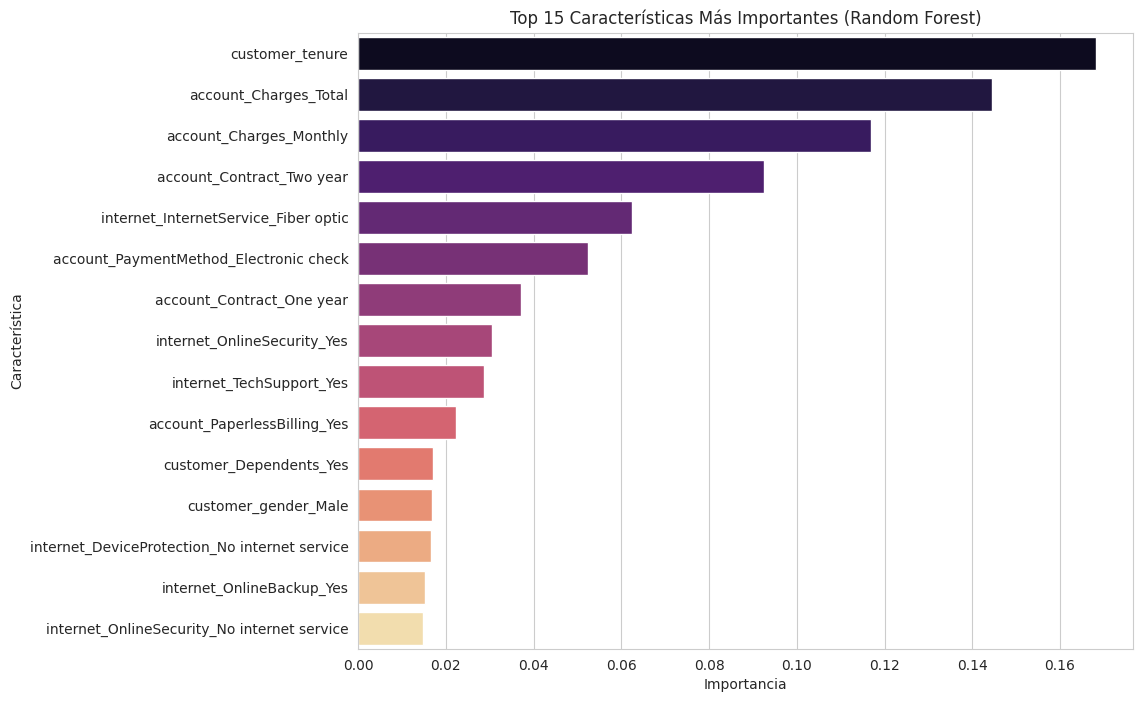


Importancia de las Características (Random Forest - Top 15):



,Feature,Importance
1,customer_tenure,0.168272
3,account_Charges_Total,0.144587
2,account_Charges_Monthly,0.116930
25,account_Contract_Two year,0.092516
10,internet_InternetService_Fiber optic,0.062483
28,account_PaymentMethod_Electronic check,0.052510
24,account_Contract_One year,0.037205
13,internet_OnlineSecurity_Yes,0.030474
19,internet_TechSupport_Yes,0.028626
26,account_PaperlessBilling_Yes,0.022407


In [80]:
import matplotlib.pyplot as plt
import seaborn as sns

# Obtener la importancia de las características del modelo Random Forest
feature_importances = pd.DataFrame({'Feature': X_train.columns, 'Importance': rf_model.feature_importances_})

# Ordenar por importancia de forma descendente
feature_importances = feature_importances.sort_values(by='Importance', ascending=False)

# Visualizar las características más importantes (ej. top 15)
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importances.head(15), palette='magma')
plt.title('Top 15 Características Más Importantes (Random Forest)')
plt.xlabel('Importancia')
plt.ylabel('Característica')
plt.show()

print("\nImportancia de las Características (Random Forest - Top 15):\n")
display(feature_importances.head(15))

#📄Informe final

## Análisis y predicción de Churn en TelecomX

### 1. Introducción
El objetivo de este proyecto fue analizar el comportamiento de churn (cancelación de servicios) de los clientes de TelecomX, identificar los factores más influyentes en esta decisión y desarrollar modelos predictivos para prever qué clientes tienen mayor probabilidad de cancelar. Esto nos permitirá proponer estrategias de retención de clientes proactivas y efectivas.

### 2. Metodología
Se realizaron los siguientes pasos en las fases de extracción de datos y análisis:
*   **Extracción y carga de datos:** se cargaron los datos de un archivo CSV que contenía información de clientes de TelecomX.
*   **Limpieza y preprocesamiento:**
    *   Se eliminó la columna `customerID` por ser un identificador único irrelevante para el modelado.
    *   Se transformaron todas las variables categóricas a un formato numérico mediante **One-Hot Encoding** para que fueran compatibles con los algoritmos de Machine Learning. La variable objetivo `Churn` se convirtió en `Churn_Yes` (True/False).
*   **Análisis exploratorio de datos:**
    *   Se analizó la distribución de la variable `Churn_Yes`, revelando un **desbalance significativo** (74.24% 'No Churn', 25.76% 'Churn'), lo cual se tuvo en cuenta en el modelado.
    *   Se visualizó una matriz de correlación acotada para identificar las relaciones entre las variables más relevantes y el `Churn_Yes`.
    *   Se exploraron las relaciones entre `customer_tenure` (tiempo de contrato) y `account_Charges_Total` (gasto total) con `Churn_Yes` mediante boxplots.
*   **Preparación para el modelado:** el conjunto de datos se dividió en entrenamiento (70%) y prueba (30%), utilizando `stratify=y` para mantener la proporción de clases en ambos subconjuntos.

*   **Modelado predictivo:** se entrenaron y evaluaron dos modelos de clasificación:
    *   **Regresión Logística:** requiere normalización de datos. Se aplicó `StandardScaler` y se usó `class_weight='balanced'` para abordar el desbalance de clases.
    *   **Random forest:** no requiere normalización de datos. También se configuró `class_weight='balanced'`.

*   **Evaluación de modelos:** se utilizaron métricas como Exactitud, Precisión, Recall, F1-Score y ROC-AUC, así como Matrices de Confusión, para evaluar y comparar el rendimiento de ambos modelos.

*   **Análisis de importancia de variables:** se investigaron los coeficientes de la Regresión Logística y la importancia de las características del Random Forest para identificar los factores clave de predicción.

### 3. Insights y factores influyentes en la cancelación
El análisis de correlación y la importancia de las variables de ambos modelos permitió identificar los siguientes factores como los más influyentes en la decisión de un cliente para cancelar sus servicios:
1.  **Tiempo de contrato (`customer_tenure`):** esta es, consistentemente, la variable más predictiva. Los clientes con **menor antigüedad** (p. ej., menos de 20-30 meses) son significativamente más propensos a cancelar. A medida que la antigüedad aumenta, la probabilidad de churn disminuye drásticamente.
2.  **Tipo de contrato (`account_Contract_Two year`, `account_Contract_One year`):** los clientes con **contratos mes a mes** tienen una probabilidad mucho mayor de churn en comparación con aquellos con contratos a largo plazo (uno o dos años). Los contratos de dos años son un fuerte indicador de lealtad.
3.  **Cargos mensuales (`account_Charges_Monthly`):** los clientes con **cargos mensuales más altos** tienden a tener una mayor propensión a cancelar. Esto sugiere que el costo percibido del servicio juega un papel crucial.
4.  **Gasto total (`account_Charges_Total`):** aunque relacionado con `customer_tenure` y `account_Charges_Monthly`, el gasto total acumulado también es un factor importante. Clientes con **menor gasto total acumulado** (lo que suele implicar menor antigüedad) son más propensos a churn.
5.  **Servicio de internet fibra óptica (`internet_InternetService_Fiber optic`):** los clientes con servicio de **fibra óptica** muestran una mayor probabilidad de cancelar. Esto podría indicar problemas de calidad, expectativas no cumplidas o un segmento de clientes más exigente.
6.  **Método de pago (`account_PaymentMethod_Electronic check`):** los clientes que utilizan **cheque electrónico** como método de pago tienen una correlación positiva con el churn, sugiriendo que este método puede estar asociado con una mayor insatisfacción o menor compromiso.
7.  **Facturación electrónica (`account_PaperlessBilling_Yes`):** los clientes que optan por la **facturación electrónica** también muestran una correlación positiva con la cancelación, lo cual podría indicar un perfil de cliente más digital y potencialmente más propenso a cambiar de proveedor si no está satisfecho.
### 4. Rendimiento y comparación de modelos
Ambos modelos predictivos lograron un rendimiento razonable en la tarea de predecir el Churn:

*   **Regresión Logística:**
    *   **ROC-AUC:** 0.8458
    *   **Recall (Churn):** 0.8075 (Identifica el 80.75% de los clientes que realmente cancelan).
    *   **Precisión (Churn):** 0.5130 (De los clientes predichos para cancelar, el 51.30% realmente lo hace).
*   **Random Forest:**
    *   **ROC-AUC:** 0.8469
    *   **Recall (Churn):** 0.7130
    *   **Precisión (Churn):** 0.5487
**Análisis crítico:**
*   **Desempeño global:** Ambos modelos exhiben un ROC-AUC similar y robusto, indicando una buena capacidad discriminativa.
*   **Balance Precisión/Recall:** La elección del modelo óptimo depende de la prioridad estratégica del negocio. Si el objetivo es maximizar la captación de clientes con riesgo de cancelación para una intervención temprana, la Regresión Logística sería la opción más adecuada. Por el contrario, si se requiere minimizar las intervenciones erróneas y ser más certero, el Random Forest ofrece un mejor desempeño.
*   **Overfitting y Underfitting:** No se observó evidencia de overfitting severo ni underfitting significativo con la información disponible, ya que ambos modelos alcanzaron un ROC-AUC y F1-score razonables en el conjunto de prueba.
### 5. Estrategias de retención basadas en los resultados
Basado en los factores influyentes identificados y el rendimiento de los modelos, se proponen las siguientes estrategias de retención:
1.  **Foco en nuevos clientes y antigüedad:** los clientes con menor antigüedad son los más propensos a cancelar. Implementar programas de bienvenida sólidos, seguimiento proactivo en los primeros meses, y ofertas especiales podrían fomentar la permanencia a largo plazo.
2.  **Incentivar contratos a largo plazo:** dado que los contratos a dos años son un fuerte indicador de lealtad, se deberían ofrecer incentivos atractivos (descuentos, beneficios exclusivos) para que los clientes opten por compromisos a más largo plazo en lugar de contratos mes a mes.
3.  **Gestión de precios y cargos mensuales:** los clientes con cargos mensuales altos son más propensos a churn. Evaluar la competitividad de los planes de precios y considerar opciones más flexibles o paquetes personalizados que ofrezcan un mayor valor percibido.
4.  **Optimización del servicio de fibra óptica:** la alta tasa de churn entre usuarios de fibra óptica es una señal de alerta. Se debe investigar a fondo las causas: ¿Problemas de calidad, atención al cliente, expectativas no cumplidas? Mejorar la experiencia en este segmento es crucial.
5.  **Monitoreo de métodos de pago y facturación electrónica:** los clientes que usan cheque electrónico y facturación electrónica muestran mayor propensión a churn. Se podrían realizar encuestas de satisfacción específicas o programas de fidelización para estos segmentos para entender mejor sus necesidades y prevenir la cancelación.
6.  **Uso de modelos predictivos para intervención:** utilizar el modelo de Regresión Logística (por su alto recall en Churn) para identificar proactivamente a los clientes con mayor riesgo de cancelación. Una vez identificados, se pueden implementar campañas de retención personalizadas (llamadas, ofertas, soporte técnico avanzado, etc.).
